In [1]:
import dill as pk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from astropy.time import Time
import datetime as dt
import glob
from pathlib import Path

from sotodlib import core
from sotodlib.core.metadata.loader import LoaderError
from sotodlib.tod_ops.flags import get_det_bias_flags

from latcom.utils import yield_utils as yd
from latcom.utils.parsing import parse_dict
from latcom.utils.optical_loading import (
    aso_tubes,
    lf_tubes,
    ot_from_ufm,
    pwv_interp,
    so_nominal_tubes,
)

%load_ext autoreload
%autoreload 2

In [2]:
ctx = core.Context("../../ctxs/smurf_det_preproc.yaml")
ufm = "mv49"
band = "090"
ot = ot_from_ufm(ufm)

start = dt.datetime(2026, 6, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2026, 6, 15, tzinfo=dt.timezone.utc)


obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)


pwv = pwv_interp()

obs_ctx_list = []
for i, obs in enumerate(obs_list):
    cur_ot = str(obs["obs_id"]).split("_")[2][3:]
    obs_id = str(obs["obs_id"])
    if cur_ot in lf_tubes:
        obs_ctx_list.append((obs_id, "../../ctxs/preprocess_lf_260604.yaml"))
    else:
        obs_ctx_list.append((obs_id, "../../ctxs/preprocess_260604.yaml"))

In [3]:
for obs_id, ctx_path in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        ctx = core.Context(ctx_path)
        break
metas = []
for obs_id, ctx_path in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        try:
            meta = ctx.get_meta(
                obs_id,
                dets={
                    "dets:stream_id": "ufm_" + str(ufm),
                    "dets:wafer.bandpass": "f" + str(band),
                },
            )
            metas.append(meta)

        except:
            continue

obs_1780451618_lati4_111
obs_1780451618_lati4_111


/global/u2/j/jorlo/dev/sotodlib/sotodlib/core/metadata/loader.py:996: MetadataSpecWarning: metadata spec contains 'unpack' and 'name' entries; ignoring the latter (except to set the 'label', maybe).
  warnings.warn(


obs_1780456042_lati4_111
obs_1780458280_lati4_111
obs_1780461905_lati4_111
obs_1780466512_lati4_111
obs_1780469106_lati4_111
obs_1780472708_lati4_111
obs_1780476312_lati4_111
obs_1780485790_lati4_111
obs_1780487541_lati4_111
obs_1780491164_lati4_111
obs_1780500457_lati4_111
obs_1780506303_lati4_111
obs_1780508760_lati4_111
obs_1780512397_lati4_111
obs_1780516000_lati4_111
obs_1780519592_lati4_111
obs_1780521698_lati4_111
obs_1780523868_lati4_111
obs_1780527481_lati4_111
obs_1780534505_lati4_111
obs_1780547839_lati4_111
obs_1780548942_lati4_111
obs_1780552546_lati4_111
obs_1780556149_lati4_111
obs_1780559751_lati4_111
obs_1780564381_lati4_111
obs_1780566939_lati4_111
obs_1780570543_lati4_111
obs_1780577678_lati4_111
obs_1780581344_lati4_111
obs_1780584941_lati4_111
obs_1780593590_lati4_111
obs_1780618059_lati4_111
obs_1780621047_lati4_111
obs_1780634280_lati4_111
obs_1780638066_lati4_111
obs_1780641656_lati4_111
obs_1780645255_lati4_111
obs_1780649881_lati4_111
obs_1780652450_lati4_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v2/preprocessing/archives//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1780656056_lati4_111', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1780683454_lati4_111
obs_1780687242_lati4_111
obs_1780692145_lati4_111
obs_1780693988_lati4_111
obs_1780697561_lati4_111
obs_1780701151_lati4_111
obs_1780706798_lati4_111
obs_1780710762_lati4_111
obs_1780714394_lati4_111


...

obs_1780963803_lati4_110
obs_1780966631_lati4_110
obs_1780971266_lati4_111
obs_1780973866_lati4_111
obs_1780974955_lati4_111
obs_1780977565_lati4_111
obs_1780981181_lati4_111
obs_1780985784_lati4_111
obs_1780988387_lati4_111
obs_1780991994_lati4_111
obs_1780995585_lati4_111
obs_1780999194_lati4_111
obs_1781003784_lati4_111
obs_1781006380_lati4_111
obs_1781009977_lati4_111
obs_1781099561_lati4_111
obs_1781103490_lati4_111
obs_1781107578_lati4_111
obs_1781111287_lati4_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v2/preprocessing/archives//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1781111287_lati4_111', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1781188885_lati4_111
obs_1781202517_lati4_111
obs_1781203936_lati4_111
obs_1781207555_lati4_111
obs_1781212027_lati4_111
obs_1781214644_lati4_111
obs_1781219244_lati4_111
obs_1781221834_lati4_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v2/preprocessing/archives//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1781221834_lati4_111', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1781222797_lati4_111
obs_1781225974_lati4_111
obs_1781229603_lati4_111
obs_1781236849_lati4_111
obs_1781240478_lati4_111
obs_1781244084_lati4_111
obs_1781247676_lati4_111
obs_1781252288_lati4_111
obs_1781254870_lati4_111
obs_1781258485_lati4_111
obs_1781262103_lati4_111
obs_1781267199_lati4_111
obs_1781268859_lati4_111
obs_1781272476_lati4_111
obs_1781276067_lati4_111
obs_1781280359_lati4_111
obs_1781285075_lati4_111
obs_1781302719_lati4_111
obs_1781306425_lati4_111
obs_1781309503_lati4_111
obs_1781311666_lati4_111
obs_1781315283_lati4_111
obs_1781318878_lati4_111
obs_1781321077_lati4_111
obs_1781322887_lati4_111
obs_1781326503_lati4_111
obs_1781330101_lati4_111
obs_1781333703_lati4_111
obs_1781338310_lati4_111
obs_1781348223_lati4_111
obs_1781351916_lati4_111
obs_1781366620_lati4_111
obs_1781370786_lati4_111
obs_1781379519_lati4_111
obs_1781382793_lati4_111
obs_1781384821_lati4_111
obs_1781386937_lati4_111
obs_1781390529_lati4_111
obs_1781394135_lati4_111
obs_1781397368_lati4_111


In [4]:
i = -1
meta = metas[i]
obs_id = meta.obs_info.obs_id
if "mv" in ufm:
    if band == "090":
        ufm_band = 1
    elif band == "150":
        ufm_band = 2
if "uv" in ufm:
    if band == "220":
        ufm_band = 1
    elif band == "280":
        ufm_band = 2
flags = get_det_bias_flags(meta).det_bias_flags
print(
    "Cut to any flag: ", len([flag for flag in np.any(flags.mask(), axis=-1) if flag])
)
meta.restrict("dets", ~core.flagman.has_any_cuts(flags))
wafer_flag = np.array([ufm in _ufm for _ufm in meta.det_info.stream_id])

if len(wafer_flag) == 0:
    print(f"No det_info for obs {obs_id}")
bp = (meta.det_cal.bg % 4) // 2

if ufm_band == 1:
    net_flag = wafer_flag * (bp == 0)
elif ufm_band == 2:
    net_flag = wafer_flag * (bp == 1)
wnoise = meta.preprocess.noiseT.white_noise[net_flag] * 1e6
ndet = len(np.where(wnoise != 0)[0])
print(
    "Cut to white noise: ",
    len(np.any(flags.mask(), axis=-1))
    - len([flag for flag in np.any(flags.mask(), axis=-1) if flag])
    - ndet,
)

Cut to any flag:  18
Cut to white noise:  111


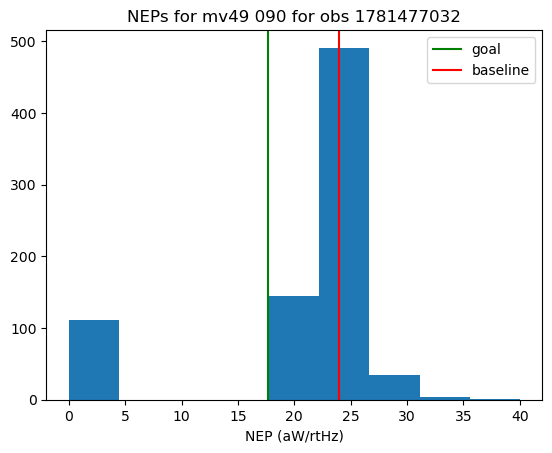

In [5]:
plt.hist(wnoise, bins=np.linspace(0, 40, 10))
plt.axvline(17.7, label="goal", c="green")
plt.axvline(24.0, label="baseline", c="red")
plt.legend()
plt.title("NEPs for {} {} for obs {}".format(ufm, band, obs_id.split("_")[1]))
plt.xlabel("NEP (aW/rtHz)")

output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"NEP_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"NEP_{ufm}_{band}.png", dpi=600)

# SO Nominal 

In [6]:
start = dt.datetime(2025, 10, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2025, 10, 15, tzinfo=dt.timezone.utc)


obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)

obs_ids_list = []
for i, obs in enumerate(obs_list):
    obs_ids_list.append(str(obs["obs_id"]))

In [7]:
old_ctx = core.Context("../../ctxs/old_smurf_det_preproc.yaml")
metas = []
for obs_id in obs_ids_list:
    if ot in obs_id:
        print(obs_id)
        try:
            meta = old_ctx.get_meta(
                obs_id,
                dets={
                    "dets:stream_id": "ufm_" + str(ufm),
                    "dets:wafer.bandpass": "f" + str(band),
                },
            )
            metas.append(meta)

        except:
            continue

obs_1759277309_lati4_111
obs_1759279469_lati4_111
obs_1759283082_lati4_111
obs_1759286672_lati4_111
obs_1759291142_lati4_111
obs_1759293429_lati4_111
obs_1759297035_lati4_111
obs_1759300634_lati4_111
obs_1759304241_lati4_111
obs_1759307681_lati4_111
obs_1759309856_lati4_111
obs_1759313445_lati4_111
obs_1759319136_lati4_111
obs_1759321587_lati4_111
obs_1759325207_lati4_111
obs_1759332347_lati4_111
obs_1759337257_lati4_111
obs_1759339814_lati4_111
obs_1759352281_lati4_111
obs_1759354032_lati4_111
obs_1759357620_lati4_111
obs_1759367543_lati4_111
obs_1759369163_lati4_111
obs_1759372751_lati4_111
obs_1759377299_lati4_111
obs_1759379466_lati4_111
obs_1759383059_lati4_111
obs_1759386659_lati4_111
obs_1759390265_lati4_111
obs_1759393847_lati4_111
obs_1759395572_lati4_111
obs_1759399155_lati4_111
obs_1759404891_lati4_111
obs_1759407263_lati4_111
obs_1759410834_lati4_111
obs_1759438885_lati4_111
obs_1759441252_lati4_111
obs_1759444834_lati4_111
obs_1759448377_lati4_111
obs_1759450536_lati4_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1759641864_lati4_111', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1759645464_lati4_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1759645464_lati4_111', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1759649066_lati4_111


...

obs_1760342959_lati4_011
obs_1760347612_lati4_011


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1760347612_lati4_011', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1760350212_lati4_011
obs_1760352771_lati4_011
obs_1760354574_lati4_011
obs_1760358154_lati4_011
obs_1760362804_lati4_011
obs_1760365375_lati4_011
obs_1760368945_lati4_011
obs_1760372556_lati4_011
obs_1760375819_lati4_011
obs_1760379753_lati4_011


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1760382339_lati4_011', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1760382339_lati4_011
obs_1760385904_lati4_011
obs_1760389778_lati4_011
obs_1760391754_lati4_011
obs_1760395472_lati4_011
obs_1760398532_lati4_011
obs_1760413537_lati4_111
obs_1760414643_lati4_111
obs_1760418111_lati4_111
obs_1760422471_lati4_111
obs_1760424904_lati4_111
obs_1760429552_lati4_111
obs_1760432126_lati4_111
obs_1760435696_lati4_111
obs_1760438975_lati4_111
obs_1760441200_lati4_111
obs_1760445841_lati4_111
obs_1760448413_lati4_111
obs_1760451976_lati4_111
obs_1760455590_lati4_111
obs_1760459186_lati4_111
obs_1760463336_lati4_111
obs_1760465802_lati4_111
obs_1760469402_lati4_111
obs_1760473001_lati4_111
obs_1760475937_lati4_111
obs_1760477904_lati4_111
obs_1760481993_lati4_111
obs_1760484766_lati4_111


In [8]:
i = -1
meta = metas[i]
obs_id = meta.obs_info.obs_id
if "mv" in ufm:
    if band == "090":
        ufm_band = 1
    elif band == "150":
        ufm_band = 2
if "uv" in ufm:
    if band == "220":
        ufm_band = 1
    elif band == "280":
        ufm_band = 2
flags = get_det_bias_flags(meta).det_bias_flags
print(
    "Cut to any flag: ", len([flag for flag in np.any(flags.mask(), axis=-1) if flag])
)
meta.restrict("dets", ~core.flagman.has_any_cuts(flags))
wafer_flag = np.array([ufm in _ufm for _ufm in meta.det_info.stream_id])

if len(wafer_flag) == 0:
    print(f"No det_info for obs {obs_id}")
bp = (meta.det_cal.bg % 4) // 2

if ufm_band == 1:
    net_flag = wafer_flag * (bp == 0)
elif ufm_band == 2:
    net_flag = wafer_flag * (bp == 1)
wnoise = meta.preprocess.noise.white_noise[net_flag] * 1e6
ndet = len(np.where(wnoise != 0)[0])
print(
    "Cut to white noise: ",
    len(np.any(flags.mask(), axis=-1))
    - len([flag for flag in np.any(flags.mask(), axis=-1) if flag])
    - ndet,
)

Cut to any flag:  19
Cut to white noise:  1


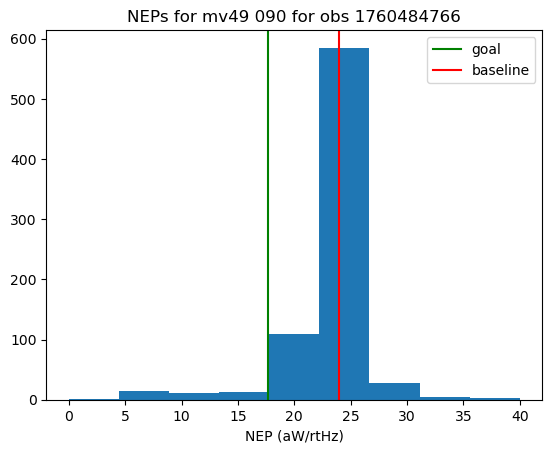

In [9]:
plt.hist(wnoise, bins=np.linspace(0, 40, 10))
plt.axvline(17.7, label="goal", c="green")
plt.axvline(24.0, label="baseline", c="red")
plt.legend()
plt.title("NEPs for {} {} for obs {}".format(ufm, band, obs_id.split("_")[1]))
plt.xlabel("NEP (aW/rtHz)")

output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"old_NEP_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"old_NEP_{ufm}_{band}.png", dpi=600)

In [10]:
len(np.any(flags.mask(), axis=-1)) - len(
    [flag for flag in np.any(flags.mask(), axis=-1) if flag]
)

781

In [11]:
ndet

780